# 04 — Precipitation Intensity Distribution Visualization

Interactive exploration of precipitation distributions at selected grid points.

**What this notebook does:**
- Pick any lat/lon point and visualize its wet-day precipitation distribution
- Overlay fitted log-normal and gamma PDFs and CDFs
- Show key fitting statistics (AIC, KS, parameters)
- Compare distributions across multiple climate regimes side by side
- QQ-plots for visual goodness-of-fit assessment

**Works with:** CPC processed data (or IMERG once downloaded)  
**Kernel:** Python (atmo)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

print('Ready.')

Ready.


---
## 1. Load data
Change `DATASET` to `'imerg'` once IMERG finishes downloading.

In [2]:
# ── CHANGE THIS ──────────────────────────────
DATASET = 'cpc'     # 'cpc' or 'imerg'
# ─────────────────────────────────────────────

proc_path = Path(f'../data/processed/{DATASET}/{DATASET}_7day_wet.nc')
stats_path = Path(f'../output/stats/{DATASET}_distribution_stats.nc')

if not proc_path.exists():
    print(f'ERROR: {proc_path} not found.')
    print('Run: python scripts/run_pipeline.py --dataset cpc --skip-maps')
else:
    da = xr.open_dataarray(str(proc_path))
    print(f'Loaded processed data: {da.sizes}')
    print(f'  Lat: {float(da.lat.min()):.2f} – {float(da.lat.max()):.2f}')
    print(f'  Lon: {float(da.lon.min()):.2f} – {float(da.lon.max()):.2f}')
    print(f'  Time: {str(da.time.values[0])[:10]} – {str(da.time.values[-1])[:10]}')

# Load pre-computed stats if available
if stats_path.exists():
    ds_stats = xr.open_dataset(str(stats_path))
    print(f'Loaded stats: {list(ds_stats.data_vars)}')
else:
    ds_stats = None
    print('Stats not yet computed — fitting will be done on the fly.')

Loaded processed data: Frozen({'time': 7305, 'lat': 104, 'lon': 236})
  Lat: 24.12 – 49.88
  Lon: -124.88 – -66.12
  Time: 2001-01-01 – 2020-12-31
Loaded stats: ['lognorm_s', 'lognorm_scale', 'gamma_a', 'gamma_scale', 'ks_lognorm', 'ks_gamma', 'pval_lognorm', 'pval_gamma', 'delta_aic', 'best_fit', 'n_wetdays']


---
## 2. Core fitting function
Run this cell once — all plot cells below call `fit_point()`.

In [3]:
DISTRIBUTIONS = {
    'Log-normal': {
        'dist': stats.lognorm,
        'fit_kwargs': {'floc': 0},
        'color': '#2166ac',
        'ls': '-',
        'param_names': ['σ (shape)', 'exp(μ) (scale)'],
    },
    'Gamma': {
        'dist': stats.gamma,
        'fit_kwargs': {'floc': 0},
        'color': '#d6604d',
        'ls': '--',
        'param_names': ['k (shape)', 'θ (scale)'],
    },
    'Weibull': {
        'dist': stats.weibull_min,
        'fit_kwargs': {'floc': 0},
        'color': '#4dac26',
        'ls': '-.',
        'param_names': ['k (shape)', 'λ (scale)'],
    },
}


def fit_point(lat, lon, wet_threshold=0.1, min_samples=30):
    """
    Extract wet-day time series at nearest grid point and fit distributions.
    
    Returns dict with 'wet' (data array) and per-distribution fit results.
    """
    ts = da.sel(lat=lat, lon=lon, method='nearest')
    actual_lat = float(ts.lat)
    actual_lon = float(ts.lon)
    
    wet = ts.values
    wet = wet[np.isfinite(wet) & (wet >= wet_threshold)]
    
    result = {
        'wet': wet,
        'lat': actual_lat,
        'lon': actual_lon,
        'n': len(wet),
        'fits': {},
    }
    
    if len(wet) < min_samples:
        print(f'Only {len(wet)} wet samples at ({actual_lat:.2f}, {actual_lon:.2f}) — too few to fit.')
        return result
    
    for name, spec in DISTRIBUTIONS.items():
        try:
            params = spec['dist'].fit(wet, **spec['fit_kwargs'])
            ll = np.sum(spec['dist'].logpdf(wet, *params))
            k = len(params) - 1  # floc=0 fixes loc, so one fewer free param
            aic = 2 * k - 2 * ll
            ks_stat, ks_pval = stats.kstest(wet, spec['dist'].cdf, args=params)
            result['fits'][name] = {
                'params': params,
                'log_likelihood': ll,
                'aic': aic,
                'ks_stat': ks_stat,
                'ks_pval': ks_pval,
            }
        except Exception as e:
            print(f'  [{name}] fit failed: {e}')
    
    # Rank by AIC (lower = better)
    if result['fits']:
        best = min(result['fits'], key=lambda n: result['fits'][n]['aic'])
        result['best'] = best
    
    return result


def _x_range(wet, extend=1.05):
    return np.linspace(wet.min() * 0.5, wet.max() * extend, 400)


print('Fitting functions ready.')

Fitting functions ready.


---
## 3. Single location: full distribution analysis

Change `LAT` and `LON` to any point over CONUS.

In [4]:
# ── CHANGE THESE ─────────────────────────────
LAT = 39.0    # Kansas City, MO (central plains)
LON = -94.5
LABEL = 'Kansas City, MO'
# ─────────────────────────────────────────────

r = fit_point(LAT, LON)
wet = r['wet']
fits = r['fits']

print(f"Location  : ({r['lat']:.2f}°N, {r['lon']:.2f}°E)  →  {LABEL}")
print(f"Wet days  : {r['n']}")
print(f"Mean      : {wet.mean():.2f} mm/day")
print(f"Median    : {np.median(wet):.2f} mm/day")
print(f"Std       : {wet.std():.2f} mm/day")
print(f"Skewness  : {stats.skew(wet):.3f}")
print(f"Kurtosis  : {stats.kurtosis(wet):.3f}")
print()
print(f"{'Distribution':<14} {'AIC':>8} {'KS stat':>9} {'KS p-val':>10}  {'Params'}")
print('-' * 70)
for name, f in sorted(fits.items(), key=lambda x: x[1]['aic']):
    pnames = DISTRIBUTIONS[name]['param_names']
    free_params = [p for i, p in enumerate(f['params']) if i != 1]  # skip loc=0
    param_str = '  '.join(f'{pn}={pv:.3f}' for pn, pv in zip(pnames, free_params))
    best_mark = ' ◄ BEST' if name == r.get('best') else ''
    print(f"{name:<14} {f['aic']:>8.1f} {f['ks_stat']:>9.4f} {f['ks_pval']:>10.4f}  {param_str}{best_mark}")

Location  : (39.12°N, -94.38°E)  →  Kansas City, MO
Wet days  : 5906
Mean      : 3.55 mm/day
Median    : 2.20 mm/day
Std       : 4.00 mm/day
Skewness  : 2.249
Kurtosis  : 6.415

Distribution        AIC   KS stat   KS p-val  Params
----------------------------------------------------------------------
Weibull         26731.8    0.0365     0.0000  k (shape)=0.934  λ (scale)=3.433 ◄ BEST
Gamma           26761.4    0.0344     0.0000  k (shape)=0.931  θ (scale)=3.812
Log-normal      26799.2    0.0529     0.0000  σ (shape)=1.231  exp(μ) (scale)=1.900


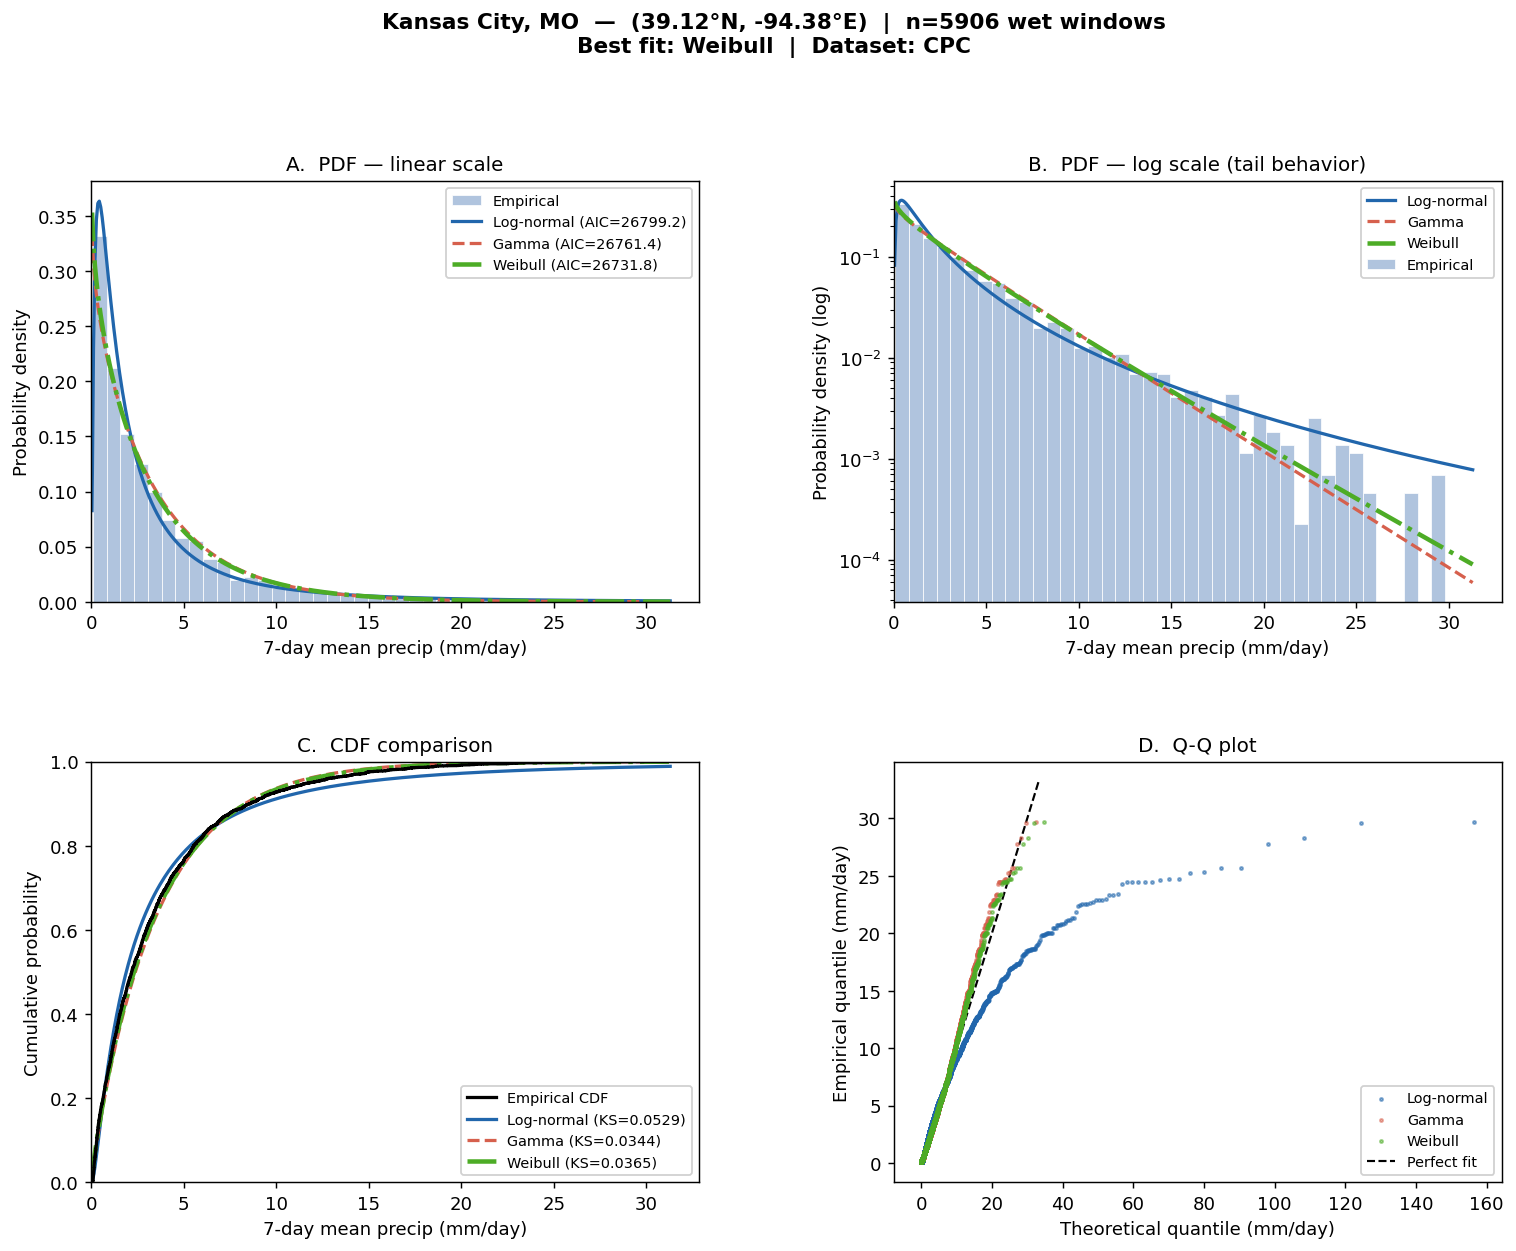

In [5]:
# ── 4-panel figure: histogram, CDF, log-scale PDF, QQ ────────────────────
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

x = _x_range(wet)
xs = np.sort(wet)
ecdf_y = np.arange(1, len(xs) + 1) / len(xs)

# --- Panel A: PDF (linear scale) ---
ax0 = fig.add_subplot(gs[0, 0])
ax0.hist(wet, bins=40, density=True, color='#b0c4de', edgecolor='white',
         linewidth=0.4, label='Empirical', zorder=1)
for name, f in fits.items():
    spec = DISTRIBUTIONS[name]
    pdf = spec['dist'].pdf(x, *f['params'])
    lw = 2.5 if name == r.get('best') else 1.8
    ax0.plot(x, pdf, color=spec['color'], ls=spec['ls'], lw=lw,
             label=f"{name} (AIC={f['aic']:.1f})", zorder=2)
ax0.set_xlabel('7-day mean precip (mm/day)')
ax0.set_ylabel('Probability density')
ax0.set_title('A.  PDF — linear scale')
ax0.legend(fontsize=8, framealpha=0.9)
ax0.set_xlim(left=0)

# --- Panel B: PDF (log y-scale — tail behavior) ---
ax1 = fig.add_subplot(gs[0, 1])
counts, bin_edges = np.histogram(wet, bins=40, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
ax1.bar(bin_centers, counts, width=np.diff(bin_edges), color='#b0c4de',
        edgecolor='white', linewidth=0.4, label='Empirical', zorder=1)
for name, f in fits.items():
    spec = DISTRIBUTIONS[name]
    pdf = spec['dist'].pdf(x, *f['params'])
    lw = 2.5 if name == r.get('best') else 1.8
    ax1.plot(x, pdf, color=spec['color'], ls=spec['ls'], lw=lw,
             label=name, zorder=2)
ax1.set_yscale('log')
ax1.set_xlabel('7-day mean precip (mm/day)')
ax1.set_ylabel('Probability density (log)')
ax1.set_title('B.  PDF — log scale (tail behavior)')
ax1.legend(fontsize=8, framealpha=0.9)
ax1.set_xlim(left=0)

# --- Panel C: CDF ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.step(xs, ecdf_y, color='black', lw=1.8, label='Empirical CDF', zorder=3)
for name, f in fits.items():
    spec = DISTRIBUTIONS[name]
    cdf = spec['dist'].cdf(x, *f['params'])
    lw = 2.5 if name == r.get('best') else 1.8
    ks = f['ks_stat']
    ax2.plot(x, cdf, color=spec['color'], ls=spec['ls'], lw=lw,
             label=f"{name} (KS={ks:.4f})", zorder=2)
ax2.set_xlabel('7-day mean precip (mm/day)')
ax2.set_ylabel('Cumulative probability')
ax2.set_title('C.  CDF comparison')
ax2.legend(fontsize=8, framealpha=0.9)
ax2.set_xlim(left=0)
ax2.set_ylim(0, 1)

# --- Panel D: QQ-plot (all distributions vs empirical) ---
ax3 = fig.add_subplot(gs[1, 1])
for name, f in fits.items():
    spec = DISTRIBUTIONS[name]
    theoretical_q = spec['dist'].ppf(ecdf_y, *f['params'])
    lw = 2.5 if name == r.get('best') else 1.8
    ax3.scatter(theoretical_q, xs, s=3, alpha=0.5, color=spec['color'],
                label=name, zorder=2)
lim = max(xs.max(), max(
    DISTRIBUTIONS[n]['dist'].ppf(0.99, *fits[n]['params'])
    for n in fits
))
ax3.plot([0, lim], [0, lim], 'k--', lw=1.2, label='Perfect fit', zorder=1)
ax3.set_xlabel('Theoretical quantile (mm/day)')
ax3.set_ylabel('Empirical quantile (mm/day)')
ax3.set_title('D.  Q-Q plot')
ax3.legend(fontsize=8, framealpha=0.9)

fig.suptitle(
    f"{LABEL}  —  ({r['lat']:.2f}°N, {r['lon']:.2f}°E)  |  n={r['n']} wet windows\n"
    f"Best fit: {r.get('best', 'N/A')}  |  Dataset: {DATASET.upper()}",
    fontsize=12, fontweight='bold', y=1.01
)
plt.show()

---
## 4. Multi-location comparison
Compare intensity distributions from climatologically distinct regions,
all overlaid on the same axes.

In [6]:
# ── CHANGE/ADD LOCATIONS ─────────────────────────────────────────────────
LOCATIONS = [
    {'lat': 47.5,  'lon': -122.3, 'label': 'Seattle (Pacific NW)'},
    {'lat': 39.0,  'lon': -94.5,  'label': 'Kansas City (Plains)'},
    {'lat': 25.8,  'lon': -80.2,  'label': 'Miami (Subtropical)'},
    {'lat': 33.5,  'lon': -112.0, 'label': 'Phoenix (Arid SW)'},
    {'lat': 44.0,  'lon': -69.8,  'label': 'Maine (NE Coast)'},
]
# ─────────────────────────────────────────────────────────────────────────

colors = ['#2166ac', '#d6604d', '#4dac26', '#8e44ad', '#e67e22']
fits_all = []
for loc in LOCATIONS:
    r = fit_point(loc['lat'], loc['lon'])
    r['label'] = loc['label']
    fits_all.append(r)

print(f"{'Location':<28} {'n':>5} {'Mean':>7} {'Std':>7} {'Skew':>7} {'Best fit':<14} {'Best AIC':>9}")
print('-' * 85)
for r, c in zip(fits_all, colors):
    if r['n'] < 30:
        print(f"{r['label']:<28} {'—':>5}  insufficient data")
        continue
    best = r.get('best', 'N/A')
    best_aic = r['fits'][best]['aic'] if best in r['fits'] else float('nan')
    print(f"{r['label']:<28} {r['n']:>5} {r['wet'].mean():>7.2f} {r['wet'].std():>7.2f} "
          f"{stats.skew(r['wet']):>7.3f} {best:<14} {best_aic:>9.1f}")

Location                         n    Mean     Std    Skew Best fit        Best AIC
-------------------------------------------------------------------------------------
Seattle (Pacific NW)          5981    3.36    3.41   1.927 Gamma            26447.3
Kansas City (Plains)          5906    3.55    4.00   2.249 Weibull          26731.8
Miami (Subtropical)           6370    5.07    5.27   1.948 Weibull          33403.3
Phoenix (Arid SW)             2737    1.56    1.83   2.204 Log-normal        7620.4
Maine (NE Coast)              6690    3.64    3.35   2.026 Gamma            30500.0


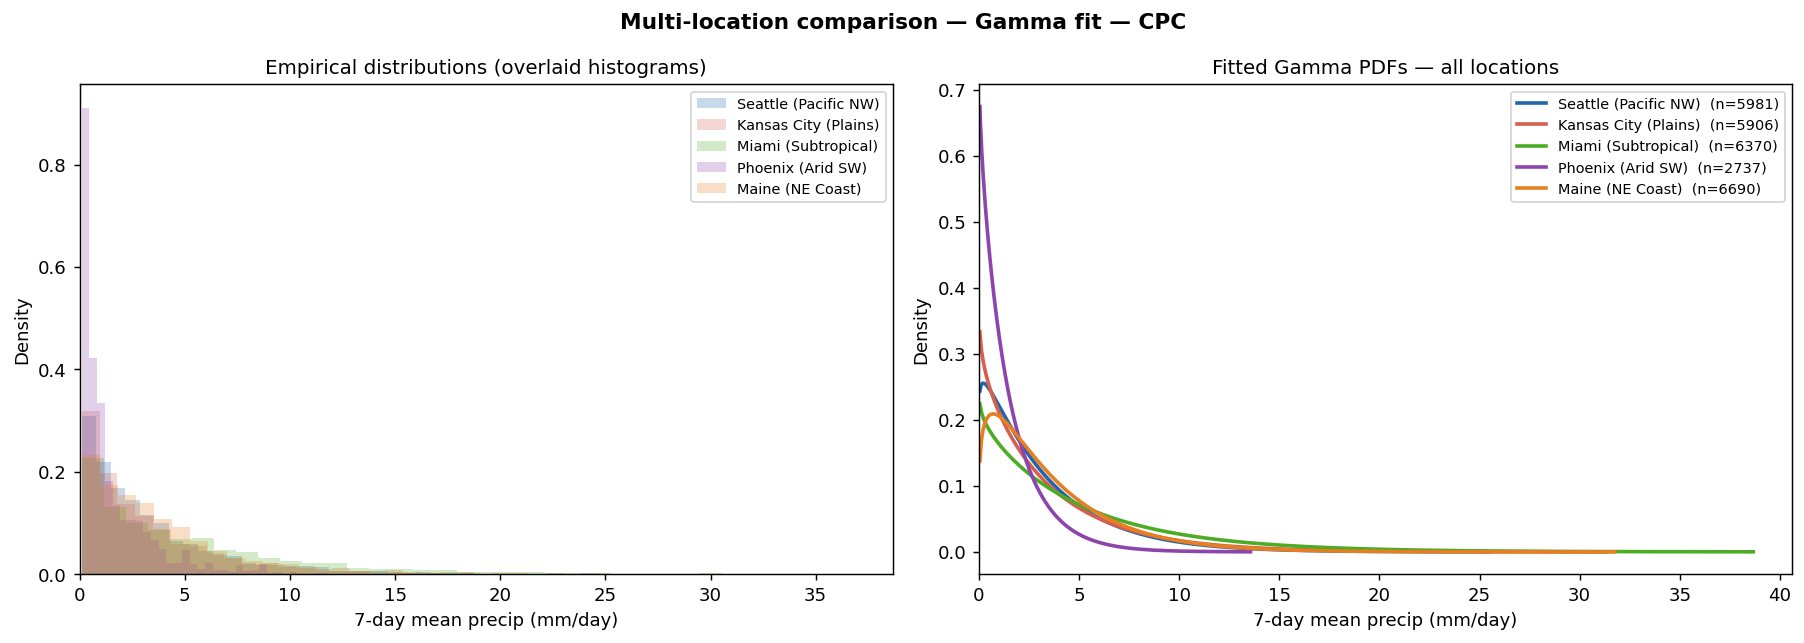

In [7]:
# ── Choose which distribution family to overlay ───────────────────────────
OVERLAY_DIST = 'Gamma'   # 'Log-normal', 'Gamma', or 'Weibull'
# ─────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r, color in zip(fits_all, colors):
    if r['n'] < 30 or OVERLAY_DIST not in r['fits']:
        continue
    wet = r['wet']
    f = r['fits'][OVERLAY_DIST]
    spec = DISTRIBUTIONS[OVERLAY_DIST]
    x = _x_range(wet)
    
    # Panel 1: Empirical histograms (normalized density)
    axes[0].hist(wet, bins=35, density=True, alpha=0.25, color=color,
                 edgecolor='none', label=r['label'])
    
    # Panel 2: Fitted PDFs only (cleaner comparison)
    pdf = spec['dist'].pdf(x, *f['params'])
    axes[1].plot(x, pdf, color=color, lw=2,
                 label=f"{r['label']}  (n={r['n']})")

axes[0].set_xlabel('7-day mean precip (mm/day)')
axes[0].set_ylabel('Density')
axes[0].set_title('Empirical distributions (overlaid histograms)')
axes[0].legend(fontsize=8)
axes[0].set_xlim(left=0)

axes[1].set_xlabel('7-day mean precip (mm/day)')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Fitted {OVERLAY_DIST} PDFs — all locations')
axes[1].legend(fontsize=8)
axes[1].set_xlim(left=0)

fig.suptitle(f'Multi-location comparison — {OVERLAY_DIST} fit — {DATASET.upper()}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. All three distributions overlaid — one panel per location

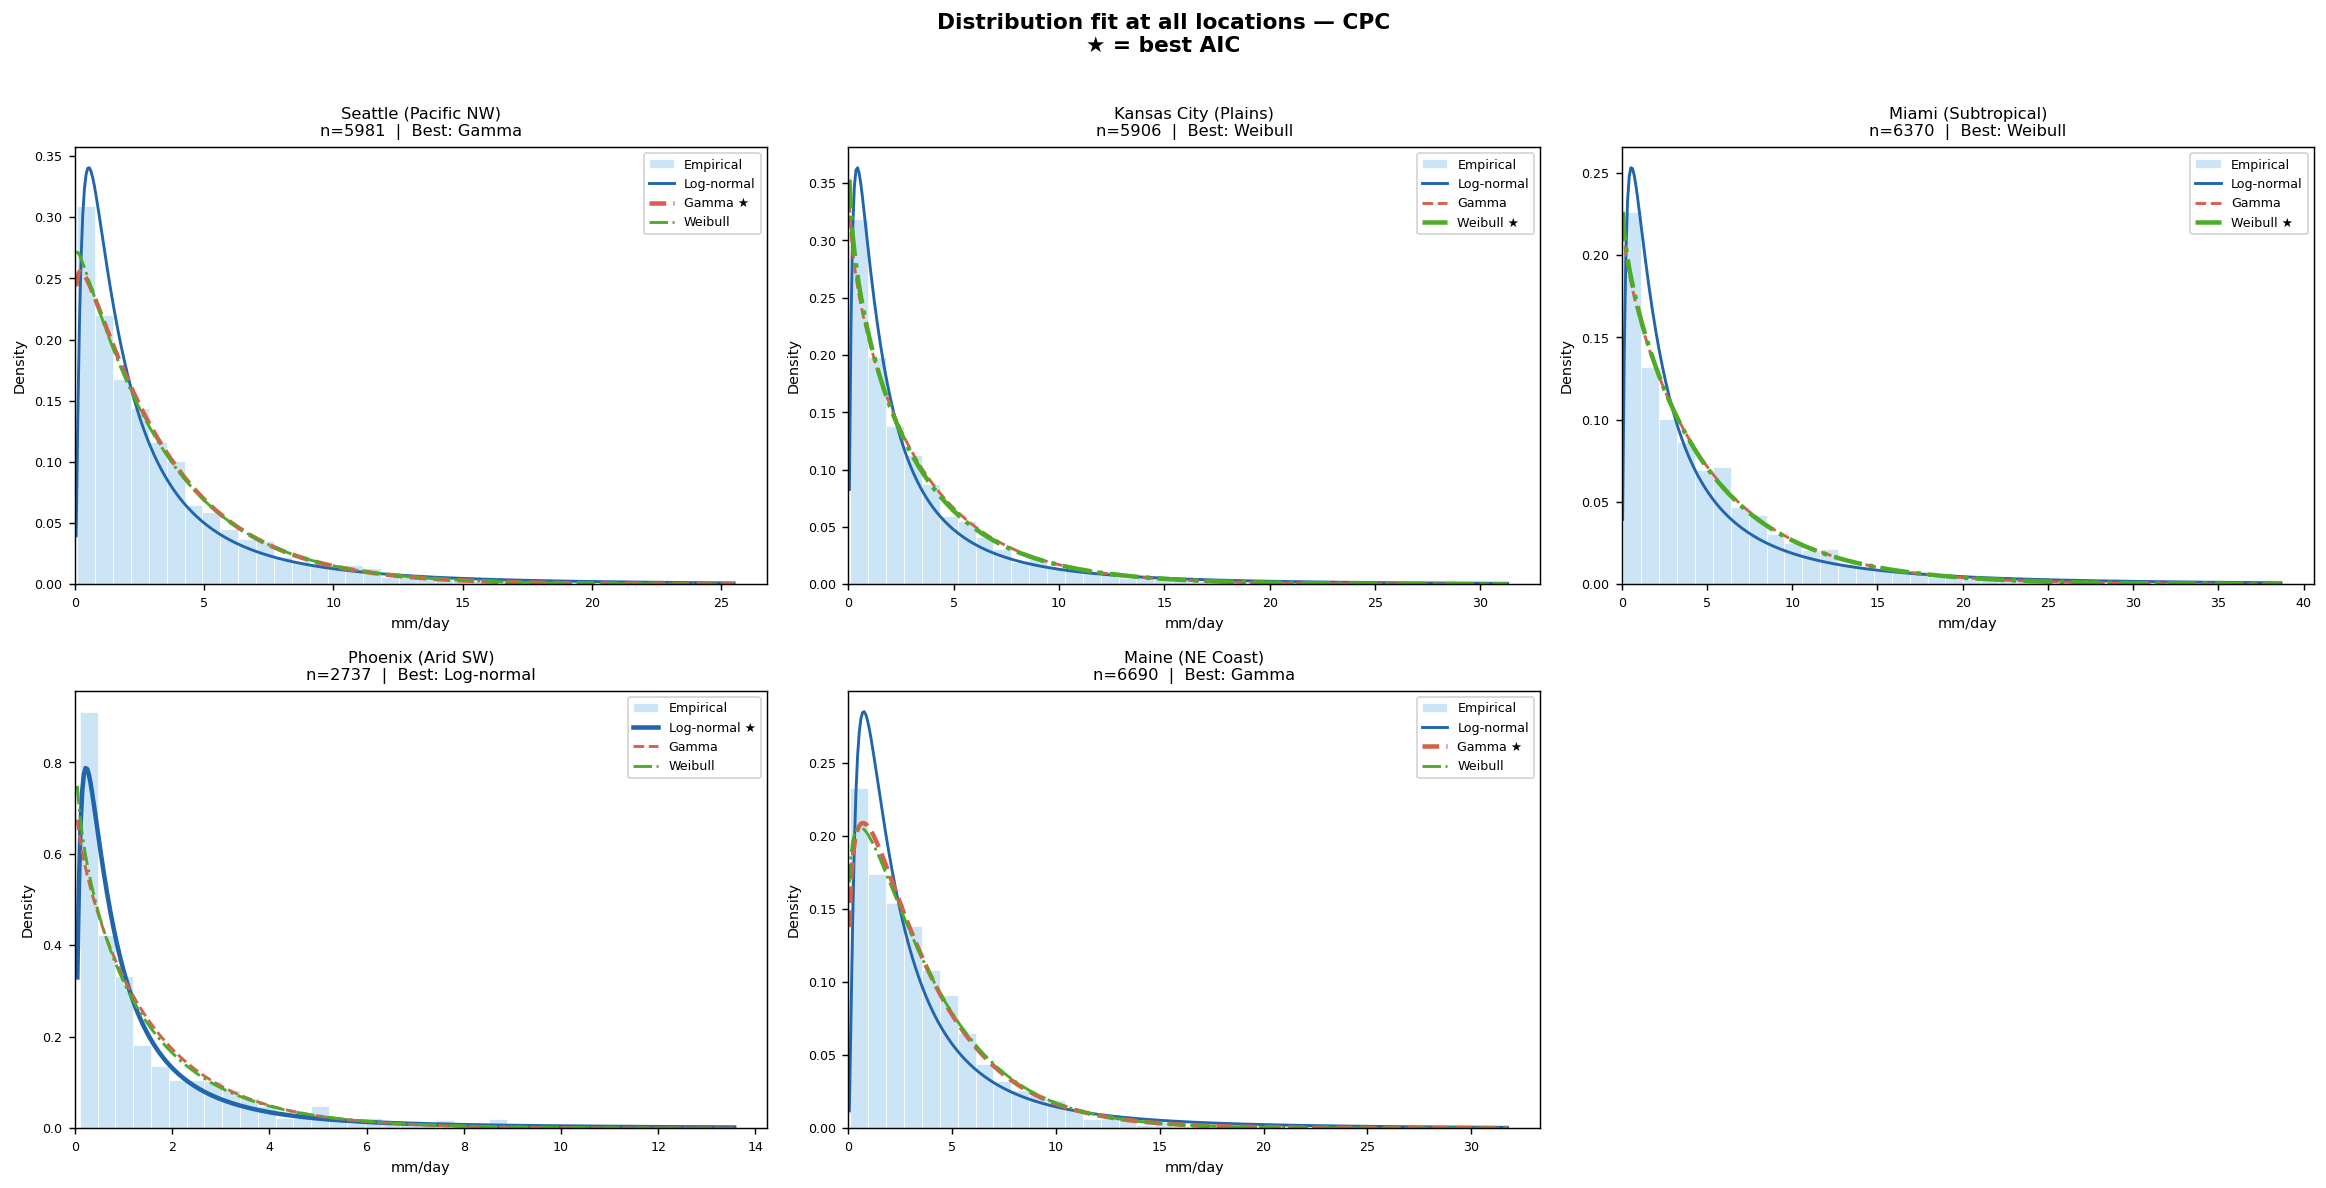

In [8]:
n_locs = sum(1 for r in fits_all if r['n'] >= 30)
ncols = min(n_locs, 3)
nrows = (n_locs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(6 * ncols, 4.5 * nrows),
                         squeeze=False)
axes_flat = [ax for row in axes for ax in row]

plot_idx = 0
for r in fits_all:
    if r['n'] < 30:
        continue
    ax = axes_flat[plot_idx]
    wet = r['wet']
    x = _x_range(wet)
    
    ax.hist(wet, bins=35, density=True, color='#cce5f6',
            edgecolor='white', linewidth=0.4, label='Empirical', zorder=1)
    
    for name, f in r['fits'].items():
        spec = DISTRIBUTIONS[name]
        pdf = spec['dist'].pdf(x, *f['params'])
        lw = 2.5 if name == r.get('best') else 1.6
        label = f"{name}" + (" ★" if name == r.get('best') else "")
        ax.plot(x, pdf, color=spec['color'], ls=spec['ls'],
                lw=lw, label=label, zorder=2)
    
    best = r.get('best', '?')
    ax.set_title(f"{r['label']}\nn={r['n']}  |  Best: {best}", fontsize=9)
    ax.set_xlabel('mm/day', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(left=0)
    ax.tick_params(labelsize=7)
    plot_idx += 1

# Hide unused axes
for ax in axes_flat[plot_idx:]:
    ax.set_visible(False)

fig.suptitle(f'Distribution fit at all locations — {DATASET.upper()}\n★ = best AIC',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Return period curve (exceedance probability)
Useful for understanding extreme precipitation intensity.

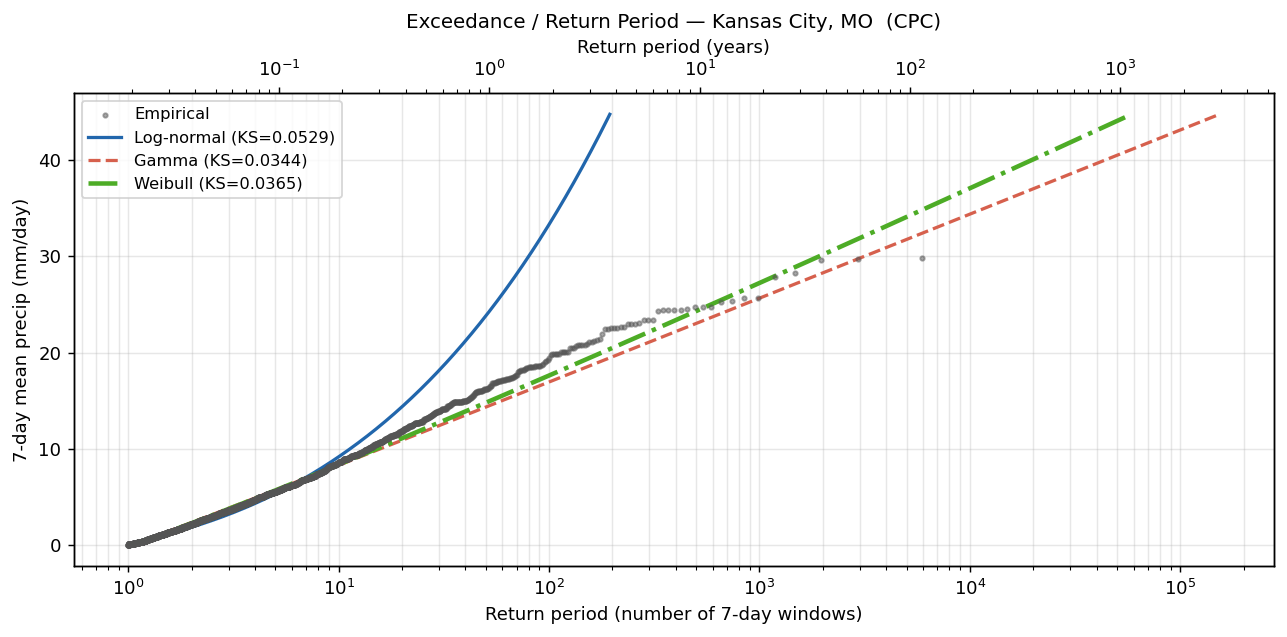

In [9]:
# ── Pick ONE location for return period analysis ──────────────────────────
LAT_RP = 39.0
LON_RP = -94.5
LABEL_RP = 'Kansas City, MO'
# ─────────────────────────────────────────────────────────────────────────

r = fit_point(LAT_RP, LON_RP)
wet = r['wet']

# Empirical exceedance probability
xs = np.sort(wet)[::-1]  # descending
exceedance = np.arange(1, len(xs) + 1) / (len(xs) + 1)
# Return period in weeks (7-day windows)
return_period = 1.0 / exceedance

x_plot = np.linspace(wet.min(), wet.max() * 1.5, 500)

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(return_period, xs, s=6, color='#555', alpha=0.5,
           label='Empirical', zorder=3)

for name, f in r['fits'].items():
    spec = DISTRIBUTIONS[name]
    # P(X > x) = 1 - CDF(x)
    exceedance_fit = 1 - spec['dist'].cdf(x_plot, *f['params'])
    # Avoid division by zero
    valid = exceedance_fit > 0
    rp_fit = 1.0 / exceedance_fit[valid]
    lw = 2.5 if name == r.get('best') else 1.8
    ax.plot(rp_fit, x_plot[valid], color=spec['color'], ls=spec['ls'],
            lw=lw, label=f"{name} (KS={f['ks_stat']:.4f})", zorder=2)

ax.set_xscale('log')
ax.set_xlabel('Return period (number of 7-day windows)')
ax.set_ylabel('7-day mean precip (mm/day)')
ax.set_title(f'Exceedance / Return Period — {LABEL_RP}  ({DATASET.upper()})')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Add secondary x-axis in years
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim([x / 52 for x in ax.get_xlim()])  # 52 weeks/year
ax2.set_xlabel('Return period (years)')

plt.tight_layout()
plt.show()

---
## 7. Map of best-fit distribution with selected points marked
Shows where your selected locations sit relative to the CONUS-wide pattern.

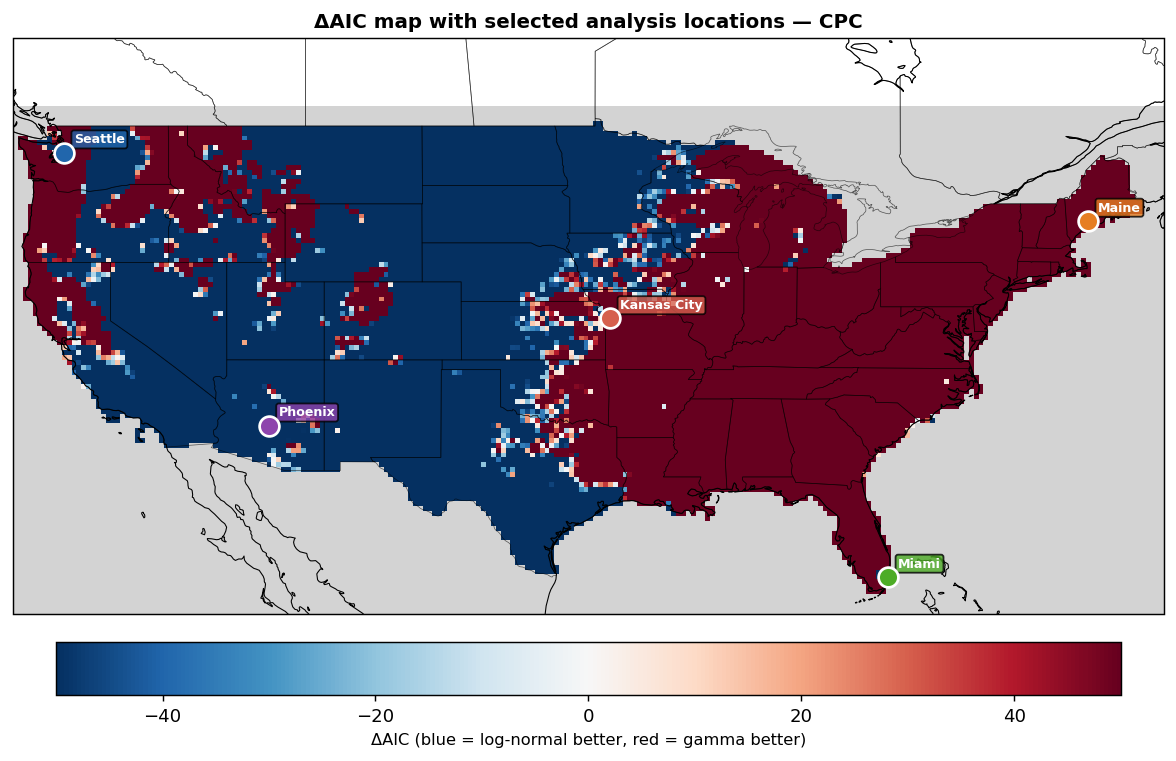

In [10]:
if ds_stats is None:
    print('Run the full pipeline first to generate stats NetCDF.')
else:
    try:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        HAS_CARTOPY = True
    except ImportError:
        HAS_CARTOPY = False

    if HAS_CARTOPY:
        fig, ax = plt.subplots(1, 1, figsize=(12, 6),
                               subplot_kw={'projection': ccrs.PlateCarree()})
        ax.set_extent([-125, -66, 24, 50])
        ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='black', alpha=0.6)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

        # ΔAIC background
        delta = ds_stats['delta_aic'].values.copy()
        mask = ds_stats['n_wetdays'].values < 30
        delta[mask] = np.nan
        cmap = plt.get_cmap('RdBu_r')
        cmap.set_bad('lightgrey')
        im = ax.pcolormesh(ds_stats.lon.values, ds_stats.lat.values, delta,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap, vmin=-50, vmax=50)
        cb = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, shrink=0.7)
        cb.set_label('ΔAIC (blue = log-normal better, red = gamma better)', fontsize=9)

        # Plot selected locations
        for r_loc, color in zip(fits_all, colors):
            if r_loc['n'] < 30:
                continue
            ax.scatter(r_loc['lon'], r_loc['lat'],
                       transform=ccrs.PlateCarree(),
                       s=120, color=color, edgecolors='white',
                       linewidths=1.5, zorder=5,
                       label=r_loc['label'])
            ax.text(r_loc['lon'] + 0.5, r_loc['lat'] + 0.5, r_loc['label'].split('(')[0].strip(),
                    transform=ccrs.PlateCarree(), fontsize=7, color='white',
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8))

        ax.set_title(f'ΔAIC map with selected analysis locations — {DATASET.upper()}',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print('cartopy not available — skipping map panel.')